<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/notebook2_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #0d47a1 0%, #1565c0 50%, #1976d2 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 2</h1>
  <h2 style="color:#bbdefb; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">LSTM — Ұзақ Қысқа Мерзімді Жады Желісі</h2>
  <p style="color:#e3f2fd; font-size:1em; margin:0;">Vanishing Gradient · Cell State · Gates · IMDB Мəтін Классификациясы</p>
</div>

## Кіріспе

SimpleRNN ұзын тізбектерде **градиент жоғалу** (vanishing gradient) проблемасына тап болады: алғашқы қадамдардың ақпараты соңғы қадамдарға жетпейді. 100 сөзді сөйлемде бірінші сөздің мəні соңғы сөзді өңдеу кезінде «ұмытылып» кетеді.

**LSTM** (Long Short-Term Memory) бұл проблеманы шешу үшін 1997 жылы ұсынылды. LSTM-нің негізгі ерекшелігі — жасуша күйі (**cell state**) арқылы ақпаратты ұзақ мерзімде сақтай алады.

Бұл зертханада IMDB кино пікірлер жинағын пайдаланып мəтін классификациясын (позитив/негатив) іске асырасыз.

## Оқу Мақсаттары

- Vanishing gradient проблемасын жəне LSTM-нің оны шешу тəсілін түсіндіре аласыз
- LSTM-нің үш қақпасын (forget, input, output) сипаттай аласыз
- Keras LSTM қабатымен мəтін классификациясы моделін жаза аласыз
- Embedding қабатының мақсатын жəне жұмысын түсінесіз
- Стекке жасалған LSTM (stacked LSTM) архитектурасын іске асыра аласыз
- SimpleRNN мен LSTM нəтижелерін салыстыра аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

In [15]:
# ============================================================
### TODO ###
# TensorFlow нұсқасын шығарыңыз.
# Кездейсоқтықты бекітіңіз (seed=42).
# ============================================================
print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.20.0


## 2-бөлім: LSTM Архитектурасы

LSTM-де əр уақыт қадамында 4 негізгі операция жүреді:

| Қақпа | Белгі | Мақсаты |
|---|---|---|
| **Forget gate** | f_t | Cell state-тен ескі ақпаратты өшіру |
| **Input gate** | i_t | Жаңа ақпаратты жазу |
| **Cell state** | C_t | Ұзақ мерзімді жады |
| **Output gate** | o_t | Hidden state шығару |

SimpleRNN-де тек 1 күй (hidden state) болса, LSTM-де 2 күй бар: **cell state** (ұзақ жады) жəне **hidden state** (қысқа жады). Cell state градиент тізбегін сақтайтын арна ретінде жұмыс жасайды.

## 3-бөлім: IMDB Деректерін Жүктеу

In [16]:
# IMDB: 50 000 кино пікір, позитив (1) немесе негатив (0)
# num_words=10000: тек ең жиі кездесетін 10 000 сөз
VOCAB_SIZE = 10000
MAX_LEN    = 200

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Үйрету жинағы:", len(x_train_raw), "пікір")
print("Тест жинағы:  ", len(x_test_raw),  "пікір")
print("\nМысал пікір (индекстер):", x_train_raw[0][:20], "...")
print("Таптар (0=neg, 1=pos):", y_train[:5])

Үйрету жинағы: 25000 пікір
Тест жинағы:   25000 пікір

Мысал пікір (индекстер): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Таптар (0=neg, 1=pos): [1 0 0 1 0]


In [17]:
# Пікір ұзындықтарын талдаймыз
lengths = [len(x) for x in x_train_raw]
print(f"Орташа ұзындық:    {np.mean(lengths):.0f}")
print(f"Медиана ұзындық:   {np.median(lengths):.0f}")
print(f"Максимум ұзындық:  {max(lengths)}")

Орташа ұзындық:    239
Медиана ұзындық:   178
Максимум ұзындық:  2494


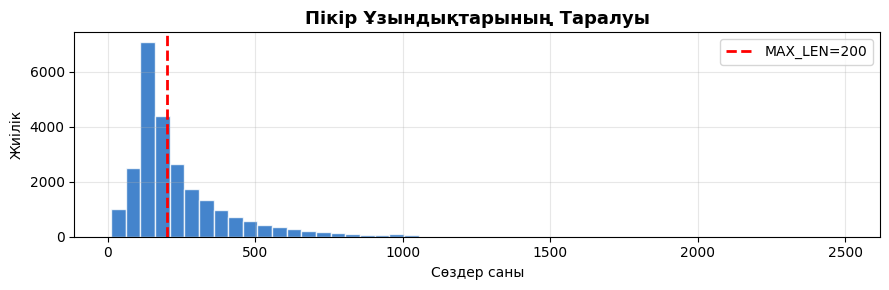

In [18]:
# ============================================================
### TODO ###
# Пікір ұзындықтарының гистограммасын бейнелеңіз (bins=50).
# MAX_LEN=200 шегін axvline арқылы белгілеңіз.
# ============================================================
plt.figure(figsize=(9, 3))
plt.hist(lengths, bins=50, color='#1565C0', edgecolor='white', alpha=0.8)
plt.axvline(x=MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Пікір Ұзындықтарының Таралуы', fontsize=13, fontweight='bold')
plt.xlabel('Сөздер саны')
plt.ylabel('Жиілік')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
### TODO ###
# pad_sequences() арқылы барлық тізбектерді MAX_LEN ұзындығына
# стандартталыңыз. truncating='post', padding='post' пайдаланыңыз.
# ============================================================
x_train = pad_sequences(
    x_train_raw,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

x_test = pad_sequences(
    x_test_raw,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Үйрету пішімі:", x_train.shape)
print("Тест пішімі:  ", x_test.shape)

Үйрету пішімі: (25000, 200)
Тест пішімі:   (25000, 200)


## 4-бөлім: Embedding Қабатын Түсіну

Мəтінді нейрондық желіге беру үшін сөздерді сандық векторларға айналдыру керек. **Embedding** — əр сөзді тығыз векторға (dense vector) кейлейтін үйренілетін кесте.

- Кіріс: бүтін сан (сөз индексі)
- Шығыс: `embedding_dim` өлшемді вектор
- Ұқсас мəнді сөздер кеңістікте жақын орналасады

Мысалы: `king - man + woman ≈ queen` — Embedding кеңістігіндегі классикалық мысал.

In [20]:
# Embedding-тің жұмысын демонстрациялаймыз
demo_embed = layers.Embedding(input_dim=100, output_dim=8)

# 5 сөздің тізбегін өткіземіз
sample_seq = tf.constant([[1, 5, 3, 20, 7]])
embedded   = demo_embed(sample_seq)

print("Кіріс (сөз индекстері):", sample_seq.numpy())
print("Шығыс пішімі:", embedded.shape)
print("Бірінші сөздің векторы:", embedded[0, 0].numpy().round(4))

Кіріс (сөз индекстері): [[ 1  5  3 20  7]]
Шығыс пішімі: (1, 5, 8)
Бірінші сөздің векторы: [ 0.0138 -0.0033  0.0425  0.0341 -0.0163  0.0308 -0.0051 -0.035 ]


## 5-бөлім: LSTM Моделін Құру

In [21]:
EMBEDDING_DIM = 64

model_lstm = keras.Sequential(name='LSTM_IMDB')

In [22]:
# Embedding қабаты: VOCAB_SIZE сөз → EMBEDDING_DIM вектор
model_lstm.add(layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    name='embedding'
))

print("Embedding қабаты қосылды.")

Embedding қабаты қосылды.


In [26]:
# ============================================================
### TODO ###
# Бірінші LSTM қабатын қосыңыз:
#   LSTM: units=64, return_sequences=True
# (Стекке жасалған LSTM үшін бірінші қабат return_sequences=True болу керек)
# ============================================================
model_lstm = keras.Sequential(name='LSTM_IMDB')

model_lstm.add(layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name='embedding'
))

model_lstm.add(layers.LSTM(
    units=64,
    return_sequences=True,
    name='lstm1'
))

print("LSTM1 қабаты қосылды.")

LSTM1 қабаты қосылды.


In [29]:
model_lstm = keras.Sequential(name='LSTM_IMDB')

model_lstm.add(layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name='embedding'
))

model_lstm.add(layers.LSTM(
    units=64,
    return_sequences=True,
    name='lstm1'
))

model_lstm.add(layers.LSTM(
    units=32,
    return_sequences=False,
    name='lstm2'
))

In [30]:
# ============================================================
### TODO ###
# Dropout(0.5) қосыңыз — артық үйренуге қарсы.
# Шығыс Dense қабатын қосыңыз:
#   units=1, activation='sigmoid'  (бинарлық классификация)
# ============================================================
model_lstm.add(layers.Dropout(0.5))
model_lstm.add(layers.Dense(1, activation='sigmoid', name='output'))

In [31]:
model_lstm.summary()

Model: "LSTM_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ============================================================
### TODO ###
# Бинарлық классификация үшін компиляциялаңыз:
#   optimizer='adam'
#   loss='binary_crossentropy'
#   metrics=['accuracy']
# ============================================================
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Компиляция аяқталды.")

Компиляция аяқталды.


## 6-бөлім: Модельді Үйрету

In [33]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True
)

print("LSTM үйретілуде...")
history_lstm = model_lstm.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("Үйрету аяқталды.")

LSTM үйретілуде...
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 430ms/step - accuracy: 0.5385 - loss: 0.6893 - val_accuracy: 0.5704 - val_loss: 0.6717
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 76s 431ms/step - accuracy: 0.6288 - loss: 0.6536 - val_accuracy: 0.6204 - val_loss: 0.6557
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 436ms/step - accuracy: 0.6667 - loss: 0.6298 - val_accuracy: 0.7028 - val_loss: 0.6083
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 427ms/step - accuracy: 0.7016 - loss: 0.5922 - val_accuracy: 0.6540 - val_loss: 0.6244
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 422ms/step - accuracy: 0.5771 - loss: 0.6706 - val_accuracy: 0.5448 - val_loss: 0.6906
Үйрету аяқталды.


## 7-бөлім: Нəтижелерді Бағалау

In [34]:
loss_lstm, acc_lstm = model_lstm.evaluate(x_test, y_test, verbose=0)
print(f"LSTM тест дəлдігі: {acc_lstm:.4f} ({acc_lstm*100:.2f}%)")

LSTM тест дəлдігі: 0.6840 (68.40%)


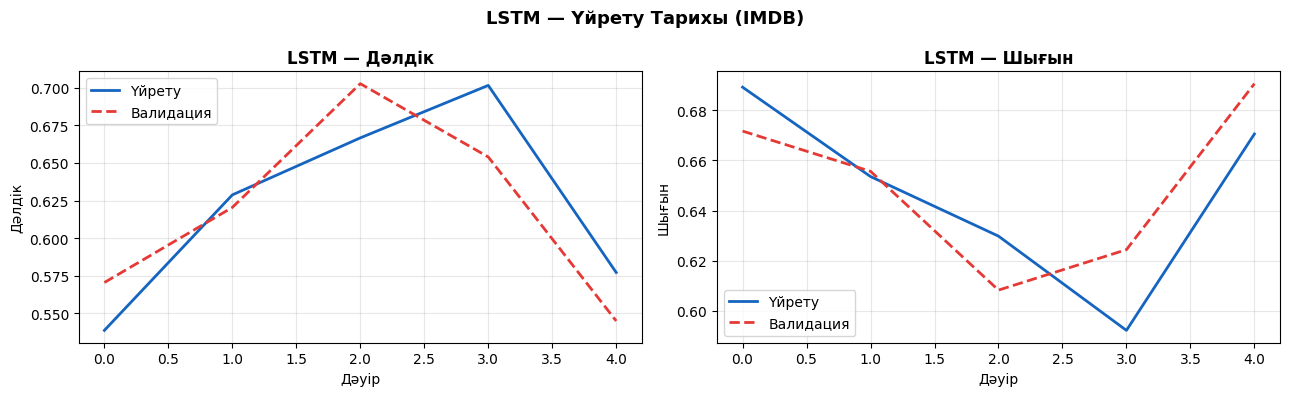

In [35]:
# ============================================================
### TODO ###
# Үйрету жəне валидация дəлдіктерін бір графикте бейнелеңіз.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_lstm.history['accuracy'],
         label='Үйрету',
         linewidth=2,
         color='#1565C0')

ax1.plot(history_lstm.history['val_accuracy'],
         label='Валидация',
         linewidth=2,
         color='#E53935',
         linestyle='--')
ax1.set_title('LSTM — Дəлдік', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дəуір')
ax1.set_ylabel('Дəлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_lstm.history['loss'],
         label='Үйрету',
         linewidth=2,
         color='#1565C0')

ax2.plot(history_lstm.history['val_loss'],
         label='Валидация',
         linewidth=2,
         color='#E53935',
         linestyle='--')
ax2.set_title('LSTM — Шығын', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дəуір')
ax2.set_ylabel('Шығын')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM — Үйрету Тарихы (IMDB)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8-бөлім: SimpleRNN мен LSTM Салыстыруы

In [36]:
# SimpleRNN базалық модель — сол деректерде
model_srnn = keras.Sequential(name='SimpleRNN_IMDB', layers=[
    layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(64, return_sequences=True),
    layers.SimpleRNN(32),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model_srnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("SimpleRNN модель:")
model_srnn.summary()

SimpleRNN модель:


Model: "SimpleRNN_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
print("SimpleRNN үйретілуде...")
history_srnn = model_srnn.fit(
    x_train, y_train,
    epochs=10, batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
_, acc_srnn = model_srnn.evaluate(x_test, y_test, verbose=0)
print(f"SimpleRNN тест дəлдігі: {acc_srnn:.4f}")

SimpleRNN үйретілуде...
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 153ms/step - accuracy: 0.5014 - loss: 0.7083 - val_accuracy: 0.4936 - val_loss: 0.6948
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 150ms/step - accuracy: 0.5669 - loss: 0.6687 - val_accuracy: 0.4864 - val_loss: 0.6999
SimpleRNN тест дəлдігі: 0.5005


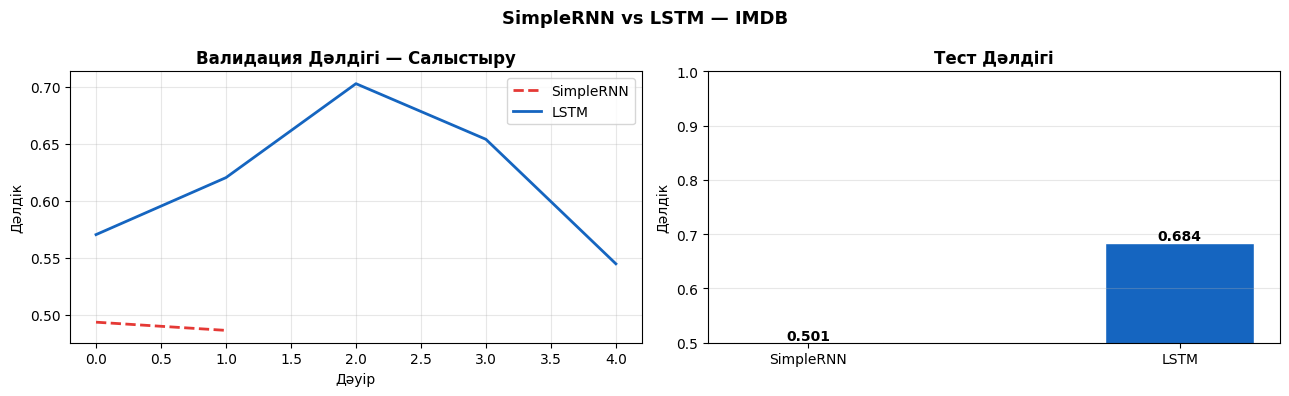

LSTM жақсартуы: +18.35%


In [38]:
# ============================================================
### TODO ###
# Екі модельдің валидация дəлдіктерін бір графикте бейнелеңіз.
# Тест дəлдіктерін bar chart-та да салыстырыңыз.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_srnn.history['val_accuracy'],
         label='SimpleRNN',
         linewidth=2,
         color='#E53935',
         linestyle='--')

ax1.plot(history_lstm.history['val_accuracy'],
         label='LSTM',
         linewidth=2,
         color='#1565C0')
ax1.set_title('Валидация Дəлдігі — Салыстыру', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дəуір')
ax1.set_ylabel('Дəлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

models_names = ['SimpleRNN', 'LSTM']
accs = [acc_srnn, acc_lstm]
ax2.bar(models_names, accs, color=['#E53935', '#1565C0'], edgecolor='white', width=0.4)
ax2.set_title('Тест Дəлдігі', fontsize=12, fontweight='bold')
ax2.set_ylabel('Дəлдік')
ax2.set_ylim(0.5, 1.0)
for i, (name, acc) in enumerate(zip(models_names, accs)):
    ax2.text(i, acc + 0.005, f'{acc:.3f}', ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('SimpleRNN vs LSTM — IMDB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"LSTM жақсартуы: {(acc_lstm - acc_srnn)*100:+.2f}%")

## 9-бөлім: Болжамдарды Интерпретациялау

In [39]:
# IMDB сөздік кестесін жүктейміз
word_index = imdb.get_word_index()
# Кері сөздік: индекс → сөз
index_to_word = {v+3: k for k, v in word_index.items()}
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'

def decode_review(encoded):
    """Индекстер тізбегін оқылатын мəтінге айналдырады."""
    return ' '.join(index_to_word.get(i, '?') for i in encoded if i > 0)

print("Мысал пікір:")
print(decode_review(x_train_raw[0])[:300], "...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Мысал пікір:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the ...


In [40]:
# ============================================================
### TODO ###
# Тест жинағынан 6 пікір таңдап болжам жасаңыз.
# model_lstm.predict() пайдаланыңыз.
# Болжам > 0.5 болса 'Позитив', əйтпесе 'Негатив' деп шығарыңыз.
# Нақты тапты жəне болжамды салыстырыңыз.
# ============================================================
sample_idx   = [0, 1, 2, 10, 50, 100]
x_sample     = x_test[sample_idx]
y_sample     = y_test[sample_idx]

preds = model_lstm.predict(
    x_sample,
    verbose=0
).flatten()

print(f"{'Нақты':<10} {'Болжам':>8} {'Сенімділік':>12} {'Дұрыс?':>8}")
print("-" * 42)
for true, pred in zip(y_sample, preds):
    label   = 'Позитив' if pred > 0.5 else 'Негатив'
    correct = (pred > 0.5) == bool(true)
    true_lb = 'Позитив' if true == 1 else 'Негатив'
    print(f"{true_lb:<10} {label:>8} {pred:>12.4f} {'Иə' if correct else 'Жоқ':>8}")

Нақты        Болжам   Сенімділік   Дұрыс?
------------------------------------------
Негатив     Негатив       0.3641       Иə
Позитив     Негатив       0.3859      Жоқ
Позитив     Позитив       0.5829       Иə
Позитив     Позитив       0.6731       Иə
Негатив     Негатив       0.3772       Иə
Позитив     Негатив       0.3641      Жоқ


## 10-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Vanishing gradient проблемасы неліктен пайда болады? LSTM оны қалай шешеді?

> Vanishing Gradient проблемасы ұзын тізбектерде градиенттердің өте кішкентай болып кетуінен пайда болады. Соның салдарынан модель алғашқы ақпаратты үйрене алмайды. LSTM forget, input және output gate арқылы маңызды ақпаратты cell state ішінде ұзақ уақыт сақтап, бұл мәселені азайтады.

**Сұрақ 2.** LSTM-де cell state мен hidden state-тің айырмасы неде? Əрқайсысы қандай ақпарат сақтайды?

> Cell state — ұзақ мерзімді жады. Ол маңызды ақпаратты көптеген уақыт қадамдары бойы сақтай алады. Hidden state — ағымдағы қадамға қажетті қысқа мерзімді ақпаратты сақтайды және келесі қабаттарға беріледі.

**Сұрақ 3.** Embedding қабатын пайдаланбасақ не болар еді? One-hot encoding мен Embedding-тің айырмасы қандай?

> Embedding болмаса сөздерді one-hot encoding арқылы көрсету керек болар еді. One-hot векторлары өте сирек (sparse) және сөздер арасындағы мағыналық ұқсастықты көрсетпейді. Embedding ықшам векторлар құрып, ұқсас сөздерді кеңістікте жақын орналастырады.

**Сұрақ 4.** Стекке жасалған LSTM (2 қабатты) бір қабатты LSTM-ден əрқашан жақсы нəтиже бере ме?

> Жоқ. Тереңірек модель күрделірек заңдылықтарды үйренуі мүмкін, бірақ параметрлер саны артып, үйрету қиындайды және артық үйрену (overfitting) қаупі өседі. Кей жағдайда бір қабатты LSTM жақсырақ жұмыс істеуі мүмкін.

**Сұрақ 5.** MAX_LEN=200 деп орнаттық. Оны 50-ге азайтсақ модельге қандай əсер болады?

> MAX_LEN=50 болса пікірлердің көп бөлігі қатты қысқарады. Маңызды ақпарат жоғалып, дәлдік төмендеуі мүмкін. Бірақ модель жылдамырақ үйренеді және жадты аз пайдаланады.

## Қорытынды

Осы зертханада сіз vanishing gradient проблемасы мен LSTM-нің оны шешу принципін түсіндіңіз, Embedding қабатының жұмысын байқадыңыз, stacked LSTM моделін IMDB деректерінде үйреттіңіз, жəне SimpleRNN мен LSTM нəтижелерін салыстырдыңыз.

<div style="background-color:#e3f2fd; border-left:5px solid #1565c0; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 3 — GRU архитектурасы жəне Bidirectional RNN.
</div>